<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_1_Classification_Basics/18_1_4_Model_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification: Predicting Credit Default: Part 3
## Model Selection via Cross-Validation

Author: Brad Sheese

---

## Introduction: Picking the Winner

Up to this point, we have used XGBoost exclusively. But just as in our regression notebooks, there are many algorithms we can choose from—Decision Trees, Random Forests, Support Vector Machines (SVMs), and more.

In this notebook, we will use cross-validation to compare multiple model types and find the one that generalizes best to unseen data. We will also explore how regularization affects XGBoost's feature selection.

### Learning Objectives
By the end of this notebook, you will be able to:
1. Compare multiple model types using cross-validation with multiple scoring metrics.
2. Understand the trade-off between goodness of fit and model complexity.
3. See how regularization (L1, L2, ElasticNet) affects which features the model relies on.

## Section 1: Setup — The Credit Default Data

We'll start by loading our familiar Credit Default data one last time to compare different algorithms.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

data = fetch_openml(name='credit-g', version=1, as_frame=True)
df = data.frame
y = (df['class'] == 'bad').astype(int)
X = df.drop(columns=['class'])
X_encoded = pd.get_dummies(X, drop_first=True)

# Clean column names for XGBoost compatibility
import re
X_encoded.columns = [re.sub(r"[<>[\]]", "_", col) for col in X_encoded.columns]

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)

# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("Data loaded and ready for competition!")


Data loaded and ready for competition!


## Section 2: Model Competition via Cross-Validation

Just like in our Regression Part 2 notebook, we don't want to rely on a single train/test split. We will use 5-fold cross-validation to find the model that generalizes best to unseen data.

We will test four competitors:
1.  **XGBoost** — Our baseline (linear decision boundary)
2.  **Decision Tree (depth=3)** — Simple, interpretable rules
3.  **Random Forest (50 trees, depth=5)** — An ensemble of many trees
4.  **SVM (RBF kernel)** — Captures complex non-linear boundaries

We'll score each model on **both accuracy and F1** — because accuracy alone can be misleading on imbalanced data.

XGBoost                  : Acc = 0.720 (+/- 0.011)  |  F1 = 0.566 (+/- 0.026)
Decision Tree (d=3)      : Acc = 0.636 (+/- 0.057)  |  F1 = 0.582 (+/- 0.037)


Random Forest            : Acc = 0.719 (+/- 0.032)  |  F1 = 0.574 (+/- 0.036)


SVM (RBF)                : Acc = 0.651 (+/- 0.021)  |  F1 = 0.320 (+/- 0.058)


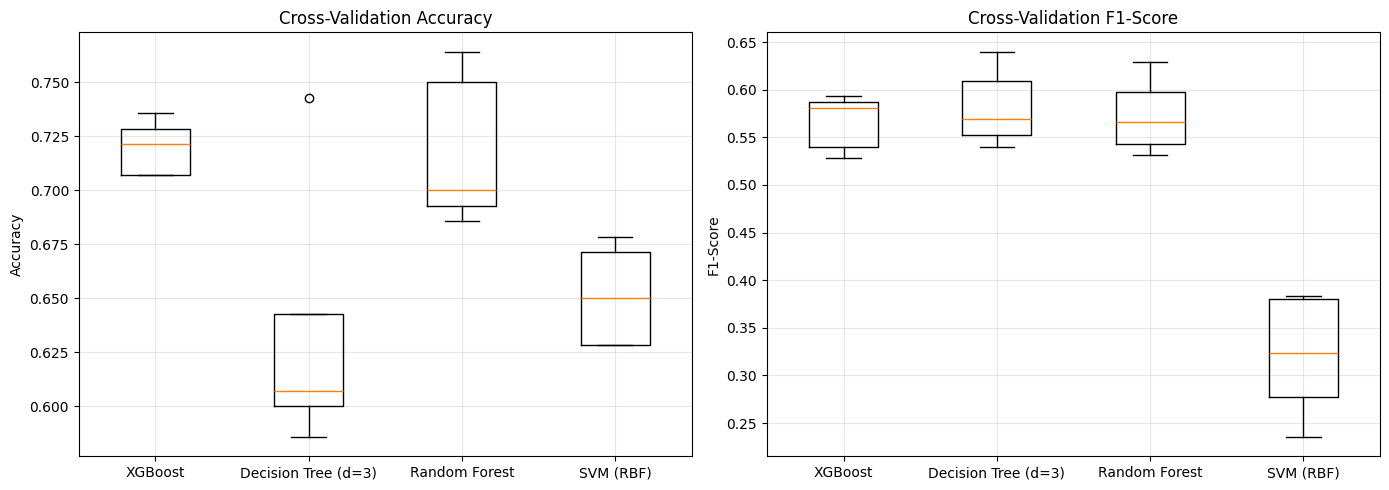

In [2]:
# Define models - using unscaled data for tree-based, scaled for SVM
models = {
    'XGBoost': (xgb.XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42
    ), X_train),
    'Decision Tree (d=3)': (DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced'), X_train),
    'Random Forest': (RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, class_weight='balanced'), X_train),
    'SVM (RBF)': (SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced'), X_train)
}

cv_accuracy = {}
cv_f1 = {}

for name, (model, X_feat) in models.items():
    acc_scores = cross_val_score(model, X_feat, y_train, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(model, X_feat, y_train, cv=5, scoring='f1')
    cv_accuracy[name] = acc_scores
    cv_f1[name] = f1_scores
    print(f"{name:<25}: Acc = {acc_scores.mean():.3f} (+/- {acc_scores.std():.3f})  |  F1 = {f1_scores.mean():.3f} (+/- {f1_scores.std():.3f})")

# Visualize both metrics side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.boxplot(cv_accuracy.values(), tick_labels=cv_accuracy.keys())
ax1.set_title('Cross-Validation Accuracy')
ax1.set_ylabel('Accuracy')
ax1.grid(True, alpha=0.3)

ax2.boxplot(cv_f1.values(), tick_labels=cv_f1.keys())
ax2.set_title('Cross-Validation F1-Score')
ax2.set_ylabel('F1-Score')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Interpreting the Results

Look at both metrics together:

- Accuracy tells you the overall correctness. A model that gets all the majority class right but misses the minority class can still have high accuracy.
- F1 tells you how well the model handles the minority class (defaults). A big gap between accuracy and F1 means the model is biased toward the majority class.

The variance (spread of each box) tells you how consistent the model is across different data splits. A wide box means the model's performance depends heavily on which specific samples end up in each fold — a sign of instability.

Notice that the XGBoost, Random Forest and SVM typically outperform the single Decision Tree. This is the power of ensembling (RF) and non-linear boundaries (SVM) over a single shallow tree.

## Conclusion

We have moved from evaluating a single model to comparing multiple algorithms. Key takeaways:

1. Cross-validation with multiple metrics is the gold standard for model comparison. Do not rely on accuracy alone.
2. Variance matters — a model with high mean but wide spread may be less reliable than a slightly lower but more consistent model.
3. XGBoost combines the power of gradient boosting with regularization, making it a strong choice for classification tasks.

So far we have worked with binary classification (good vs. bad credit). In the next notebook, we will explore what happens when there are 3 or more classes — and how models adapt to handle multiclass problems.